In [1]:
# Imports

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import (
    LabelEncoder, OneHotEncoder, StandardScaler, OrdinalEncoder
)
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score
)
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from scipy.stats import chi2_contingency
import warnings
warnings.filterwarnings("ignore")


In [2]:
# Mount Google Drive

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
# Load Data

df = pd.read_csv('/content/drive/MyDrive/dataset_B_training.csv')
target_col = "h1n1_vaccine"

print("Data Loaded Successfully")
print("Shape:", df.shape)
df.head()


Data Loaded Successfully
Shape: (4756, 31)


,respondent_id,h1n1_concern,h1n1_knowledge,behavioral_antiviral_meds,behavioral_avoidance,behavioral_face_mask,behavioral_wash_hands,behavioral_large_gatherings,behavioral_outside_home,behavioral_touch_face,...,sex,income_poverty,marital_status,rent_or_own,employment_status,census_msa,household_adults,household_children,employment_sector,h1n1_vaccine
0,1,1.0,2.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,...,Female,"<= $75,000, Above Poverty",Married,Own,Employed,"MSA, Not Principle City",2.0,1.0,construction,0
1,2,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,Female,Below Poverty,Not Married,Own,Employed,Non-MSA,0.0,3.0,wholesale,0
2,3,2.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,...,Female,"> $75,000",Not Married,Own,Employed,"MSA, Principle City",0.0,0.0,real_estate,1
3,4,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,...,Female,"<= $75,000, Above Poverty",Not Married,Rent,Not in Labor Force,Non-MSA,0.0,0.0,NaN,0
4,5,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,Female,NaN,Not Married,NaN,Unemployed,Non-MSA,3.0,0.0,NaN,0


In [4]:
#  Univariate Analysis

print("\nData types:\n", df.dtypes)
print("\nMissing values per column:\n", df.isnull().sum())

missing_summary = (
    df.isnull().sum().reset_index()
    .rename(columns={'index':'Feature', 0:'MissingCount'})
)
missing_summary['MissingPct'] = (missing_summary['MissingCount'] / len(df)) * 100
missing_summary.sort_values('MissingPct', ascending=False).head(10)



Data types:
 respondent_id                    int64
h1n1_concern                   float64
h1n1_knowledge                 float64
behavioral_antiviral_meds      float64
behavioral_avoidance           float64
behavioral_face_mask           float64
behavioral_wash_hands          float64
behavioral_large_gatherings    float64
behavioral_outside_home        float64
behavioral_touch_face          float64
doctor_recc_h1n1               float64
chronic_med_condition          float64
child_under_6_months           float64
health_worker                  float64
health_insurance               float64
opinion_h1n1_vacc_effective    float64
opinion_h1n1_risk              float64
opinion_h1n1_sick_from_vacc    float64
age_group                       object
education                       object
race                            object
sex                             object
income_poverty                  object
marital_status                  object
rent_or_own                     object
employment_

,Feature,MissingCount,MissingPct
29,employment_sector,2364,49.705635
14,health_insurance,1925,40.475189
22,income_poverty,712,14.970563
10,doctor_recc_h1n1,319,6.707317
24,rent_or_own,315,6.623213
25,employment_status,235,4.941127
23,marital_status,226,4.751892
19,education,224,4.709840
11,chronic_med_condition,161,3.385198
12,child_under_6_months,134,2.817494


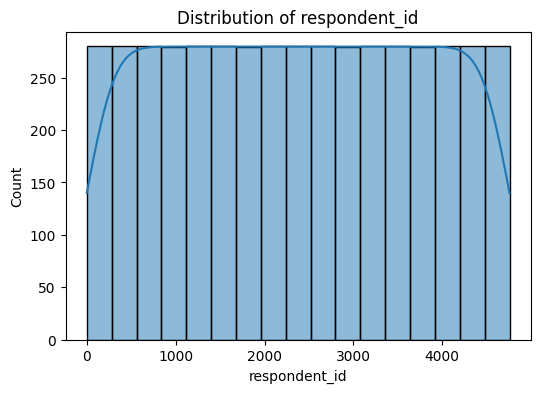

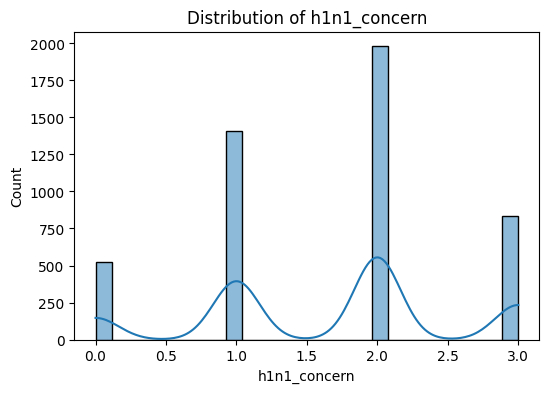

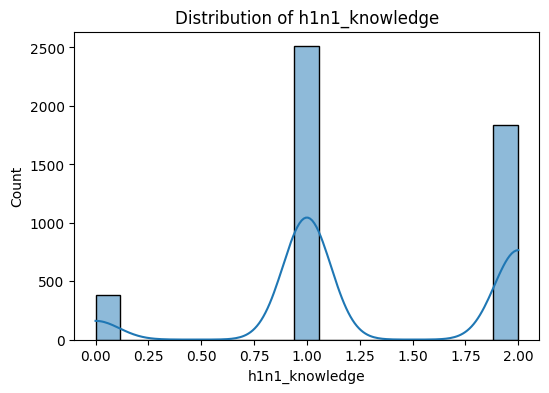

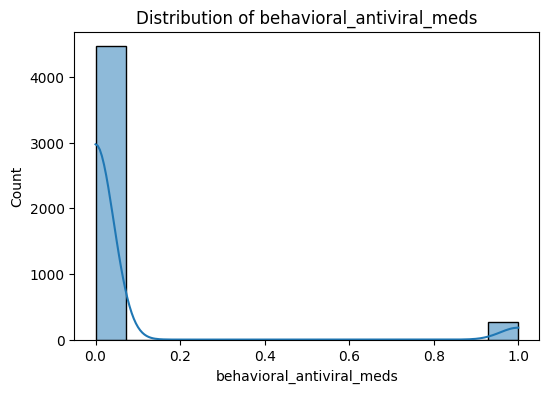

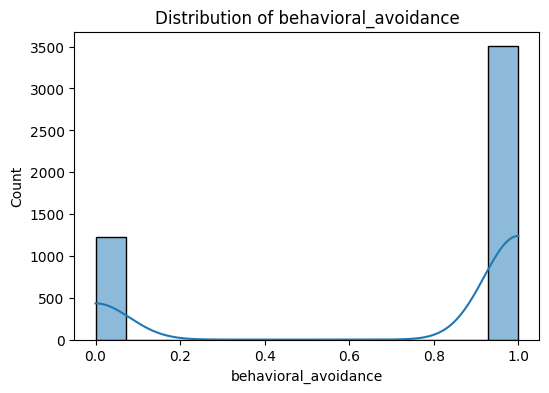

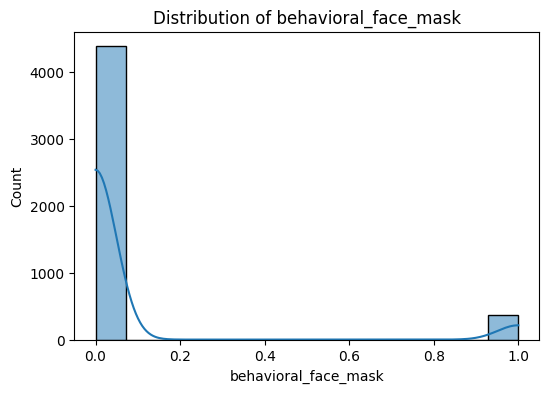

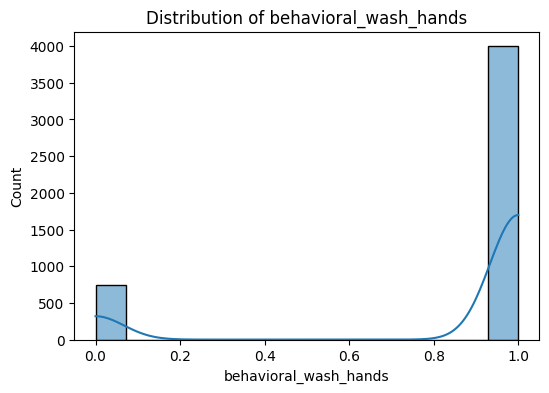

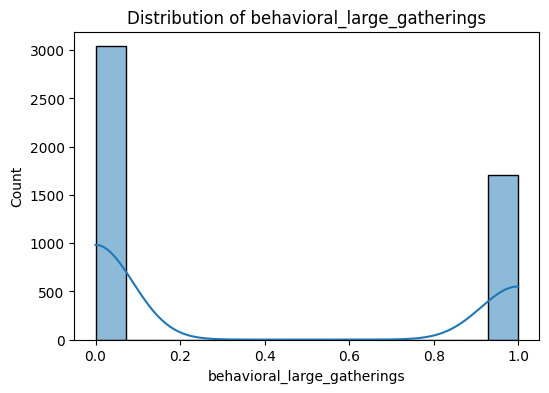

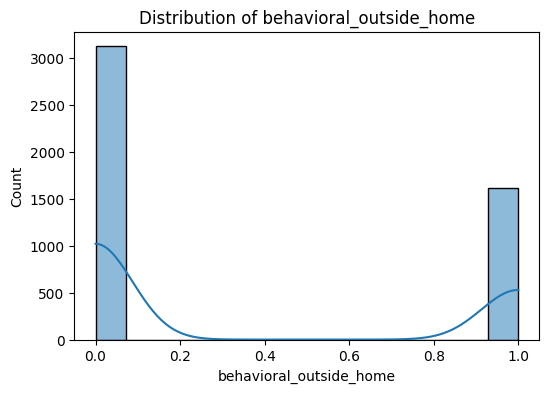

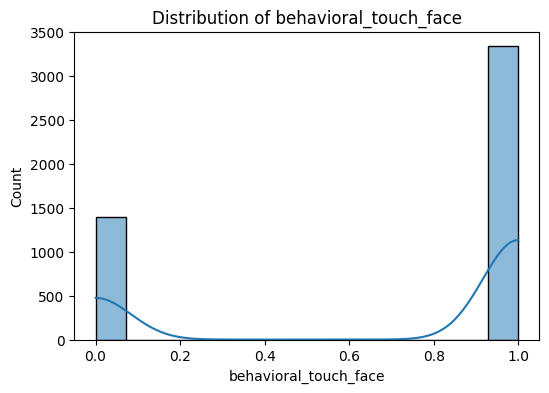

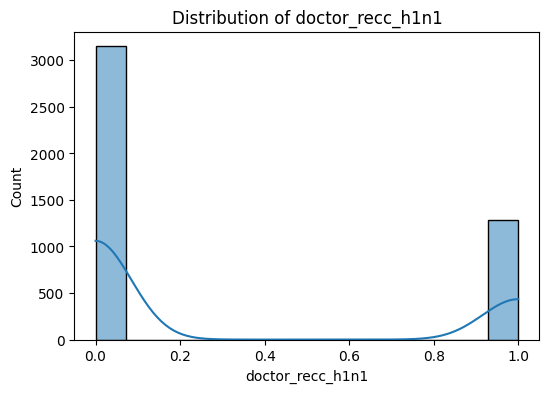

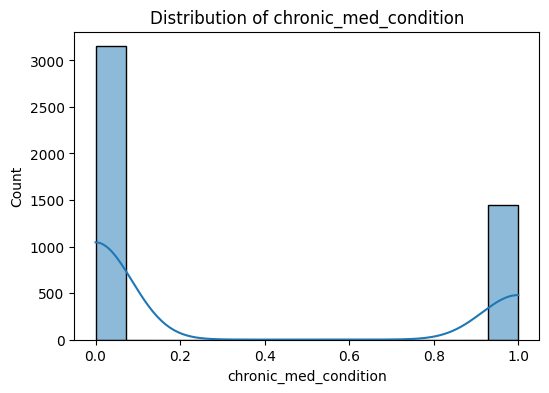

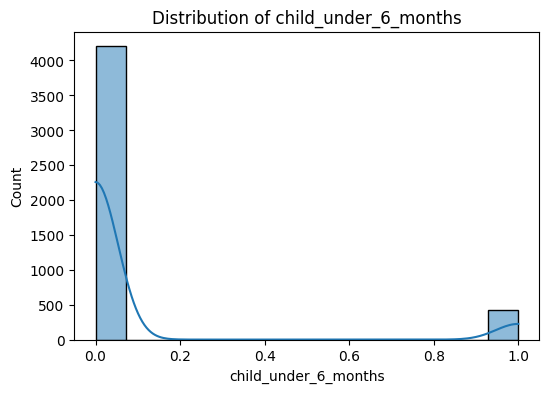

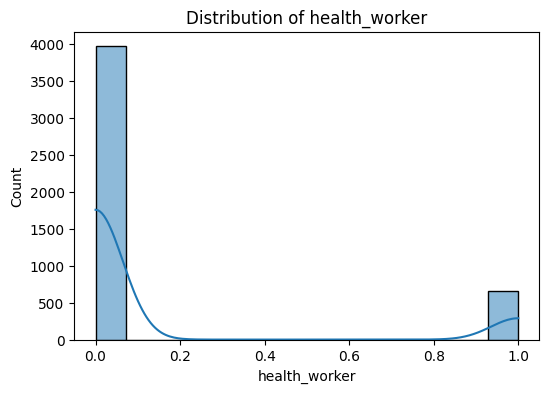

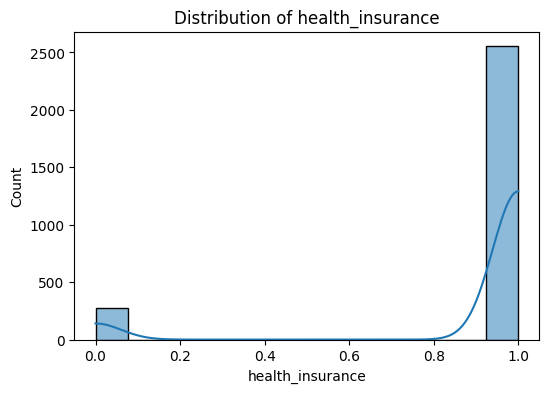

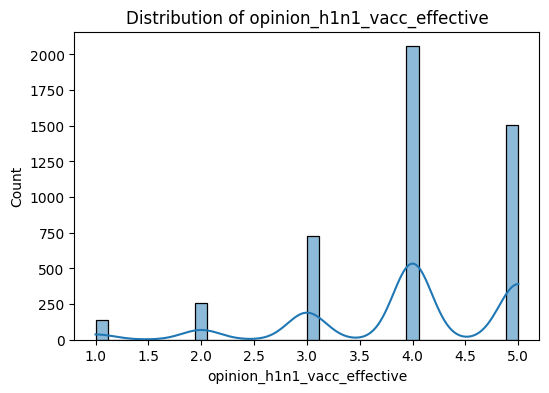

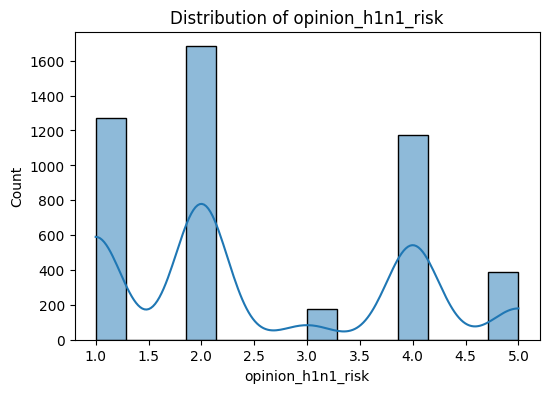

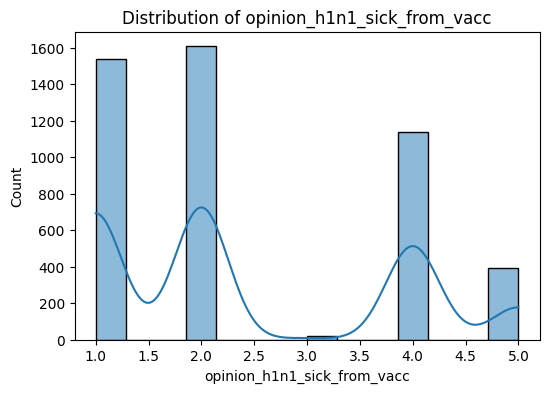

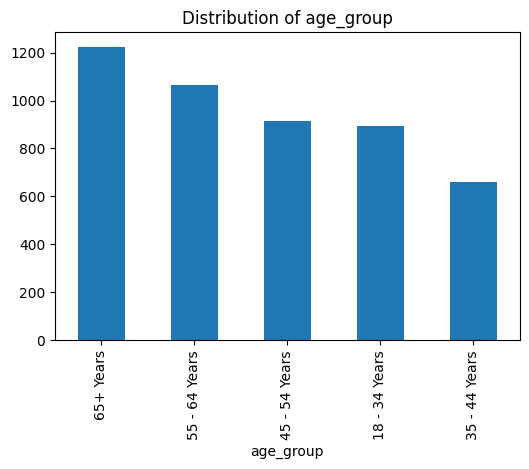

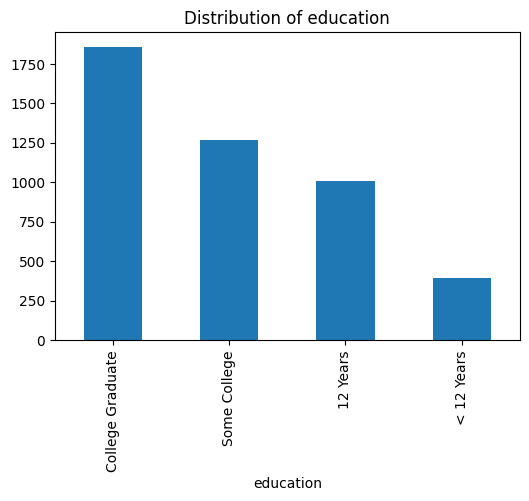

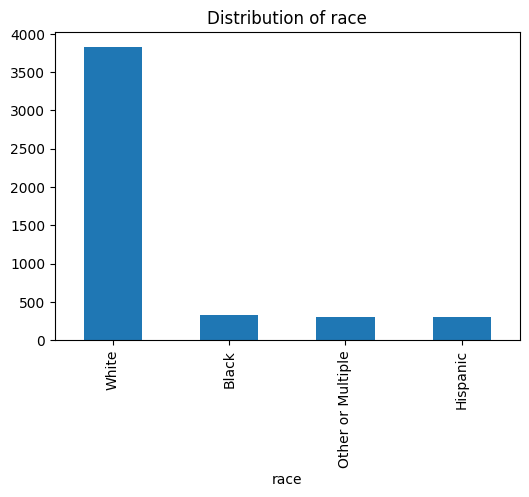

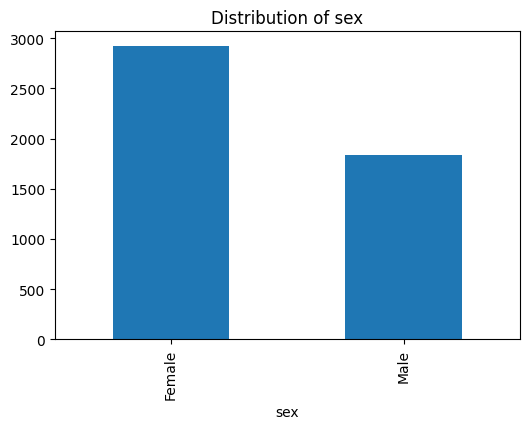

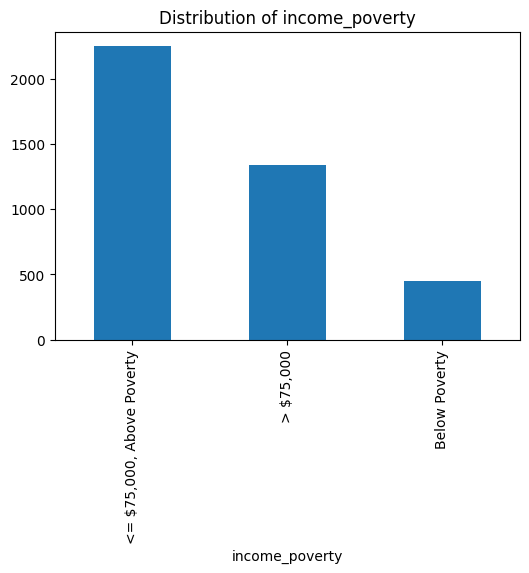

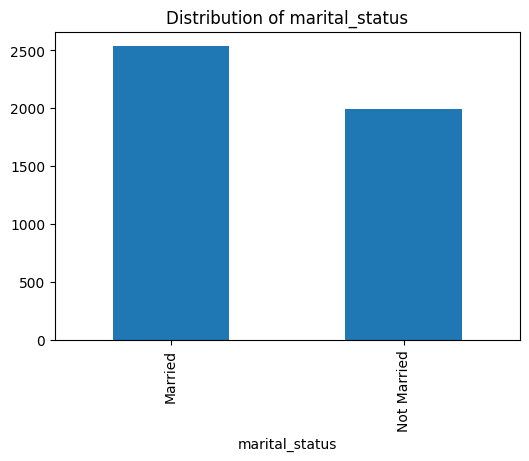

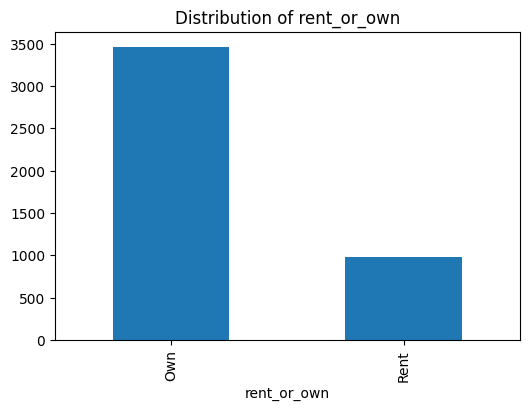

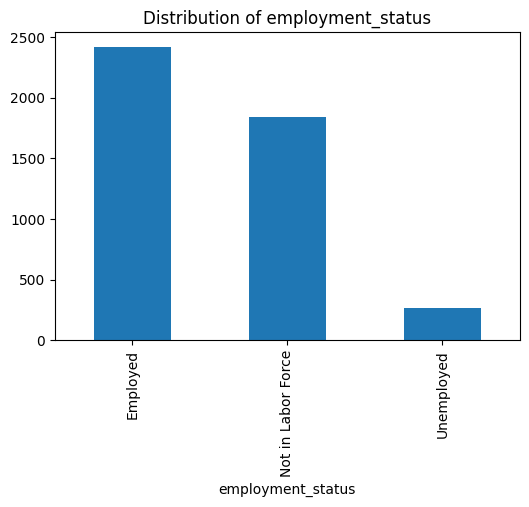

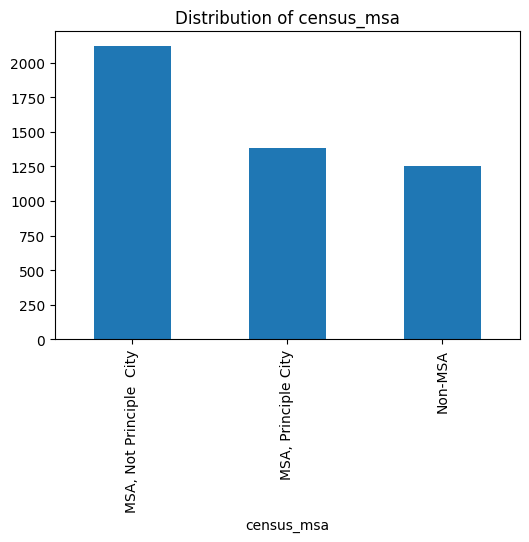

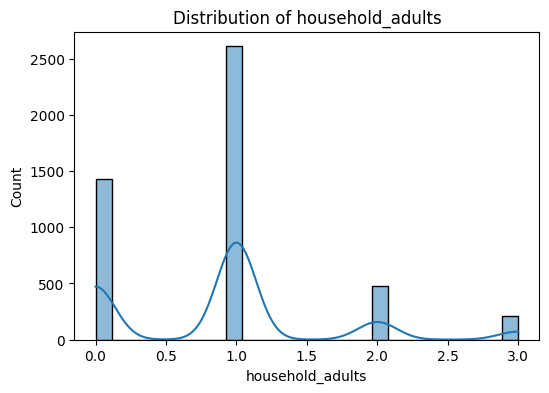

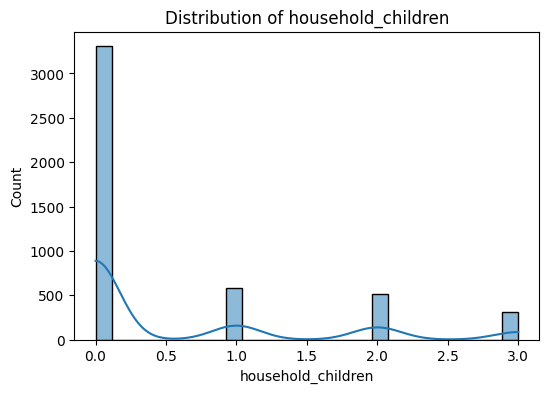

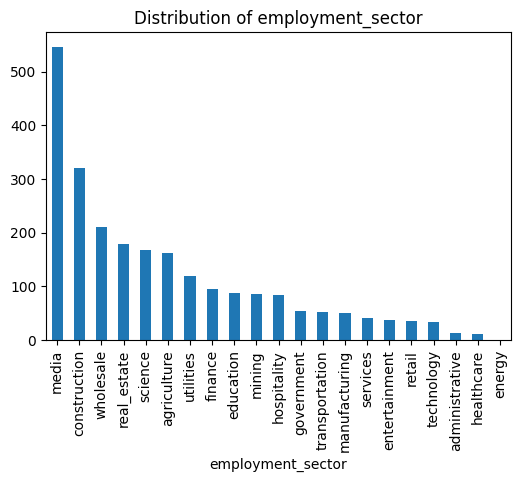

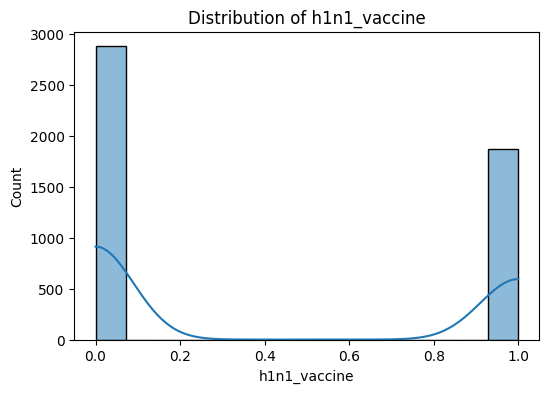

In [5]:
#  Histograms and Bar plots
for col in df.columns:
    plt.figure(figsize=(6,4))
    if df[col].dtype in ["int64", "float64"]:
        sns.histplot(df[col], kde=True)
    else:
        df[col].value_counts().plot(kind='bar')
    plt.title(f"Distribution of {col}")
    plt.show()


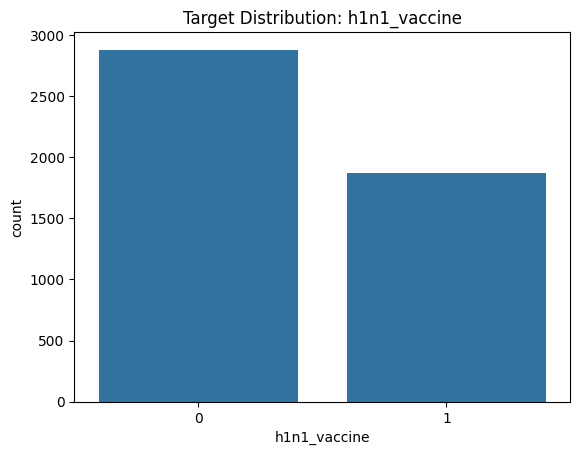

In [6]:
# --- Target distribution ---
target_col = "h1n1_vaccine"
if target_col in df.columns:
    sns.countplot(x=target_col, data=df)
    plt.title("Target Distribution: h1n1_vaccine")
    plt.show()


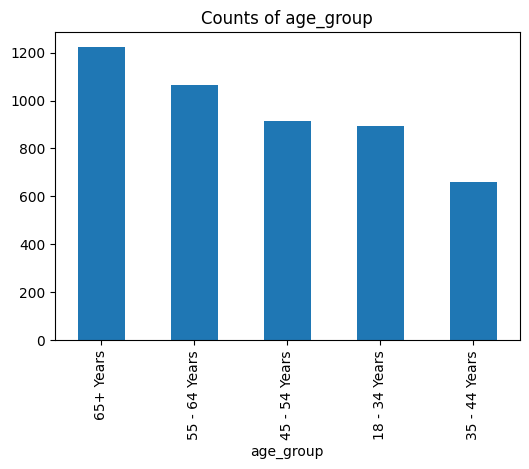

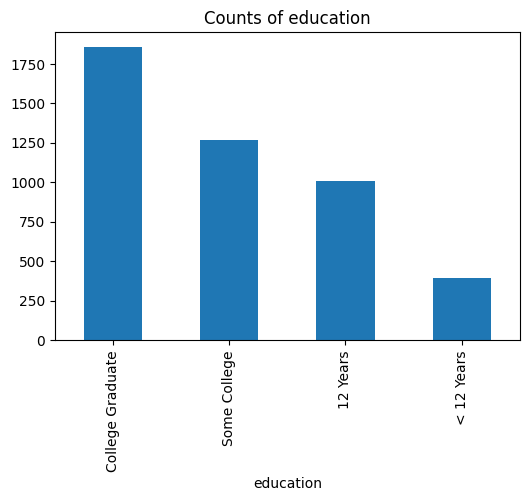

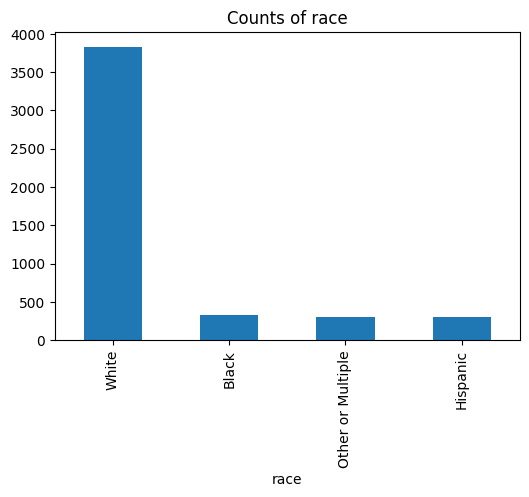

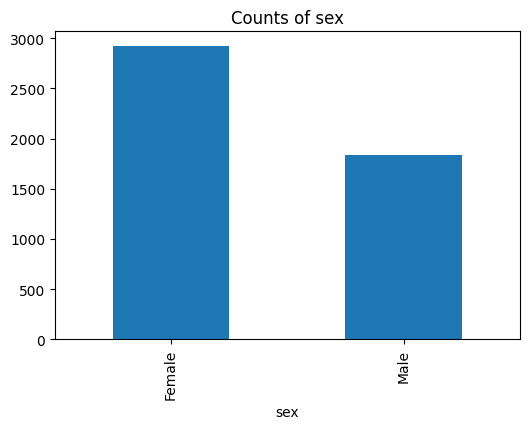

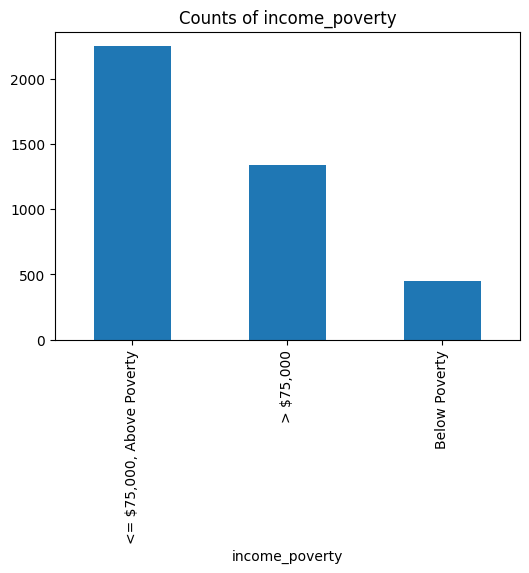

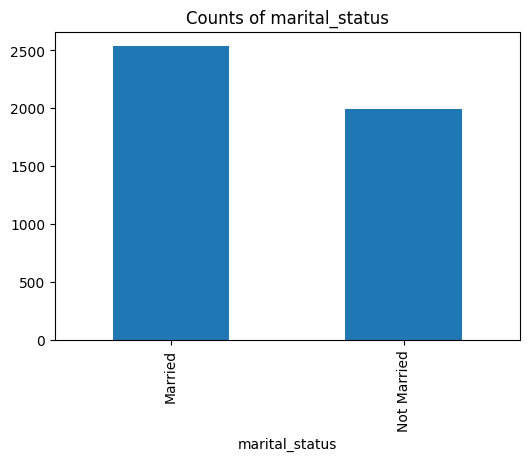

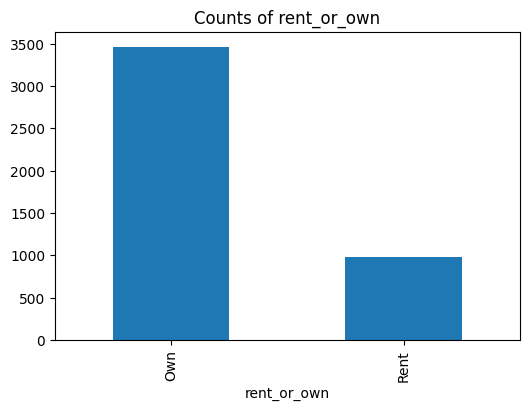

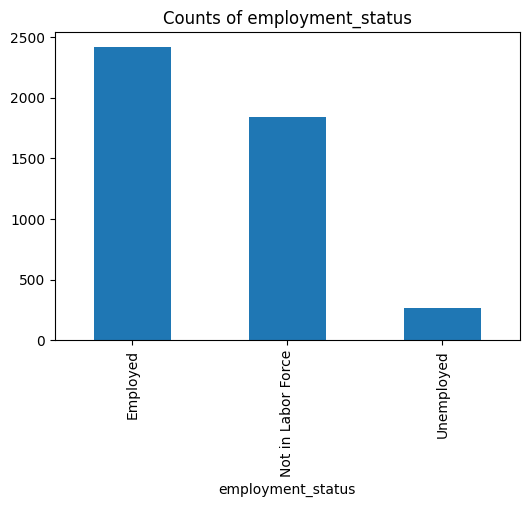

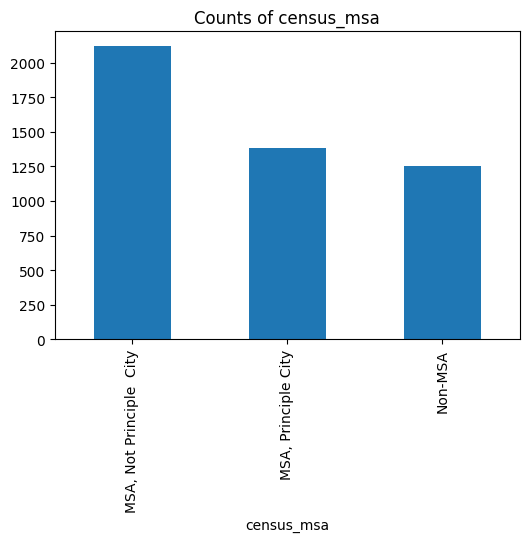

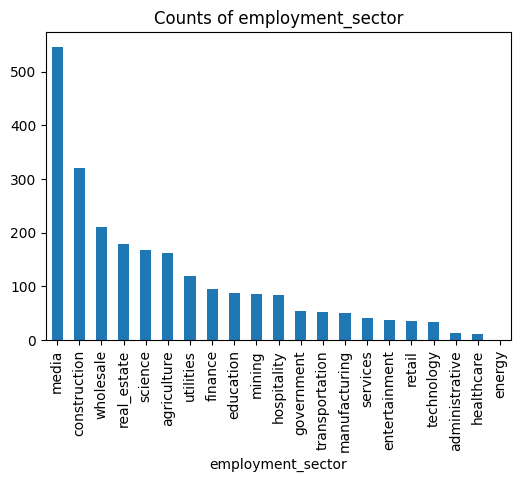

In [7]:
# Categorical variable counts
cat_cols = df.select_dtypes(include=["object", "category"]).columns
for col in cat_cols:
    plt.figure(figsize=(6,4))
    df[col].value_counts().plot(kind='bar')
    plt.title(f"Counts of {col}")
    plt.show()


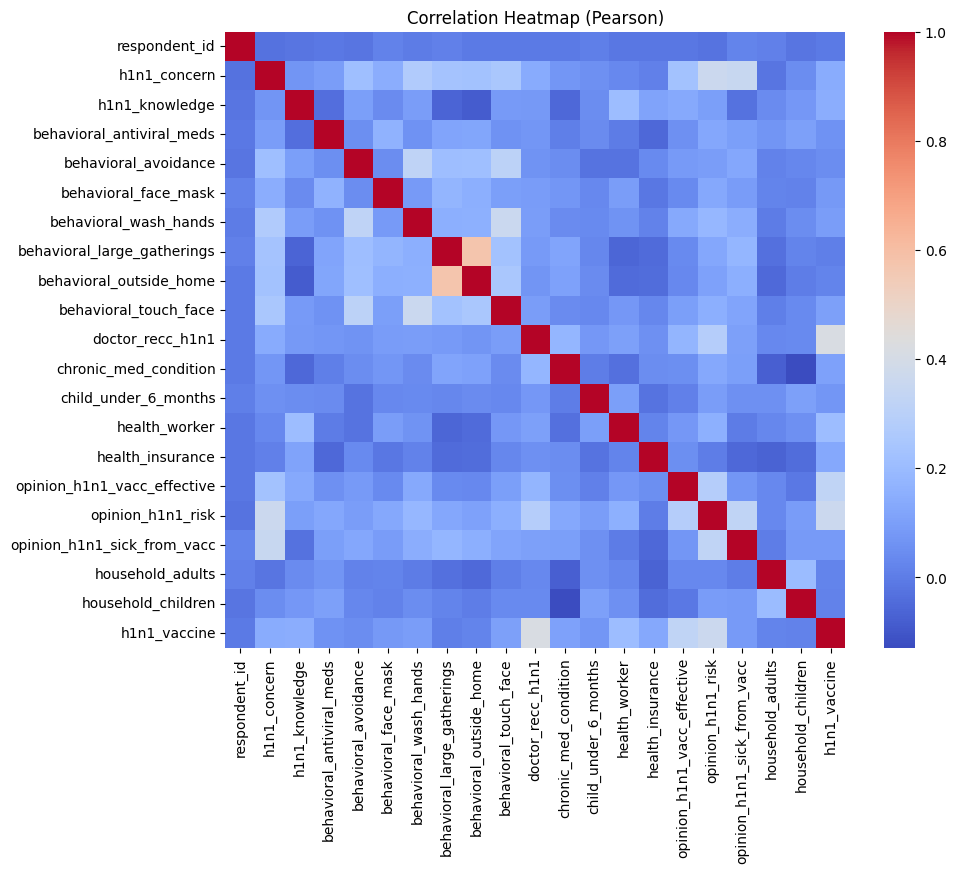

In [8]:

# Bivariate Analysis

# Numeric Correlations Heatmap
num_cols = df.select_dtypes(include=np.number).columns
corr = df[num_cols].corr(method='pearson')
plt.figure(figsize=(10,8))
sns.heatmap(corr, cmap="coolwarm", annot=False)
plt.title("Correlation Heatmap (Pearson)")
plt.show()


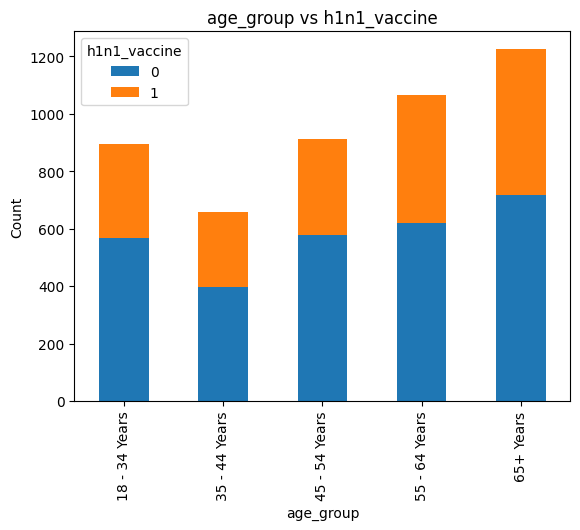

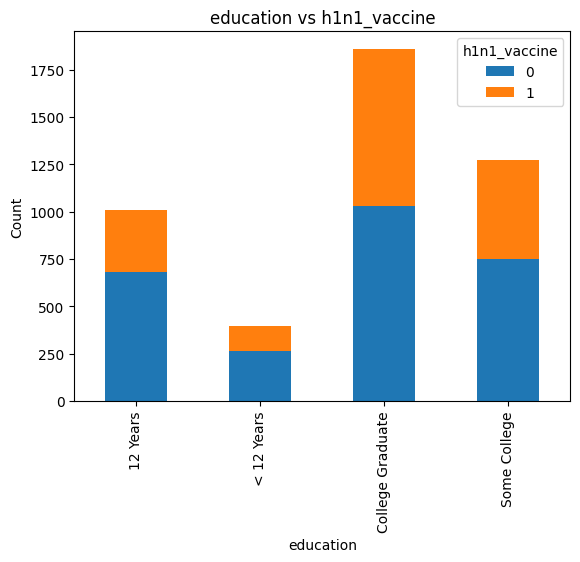

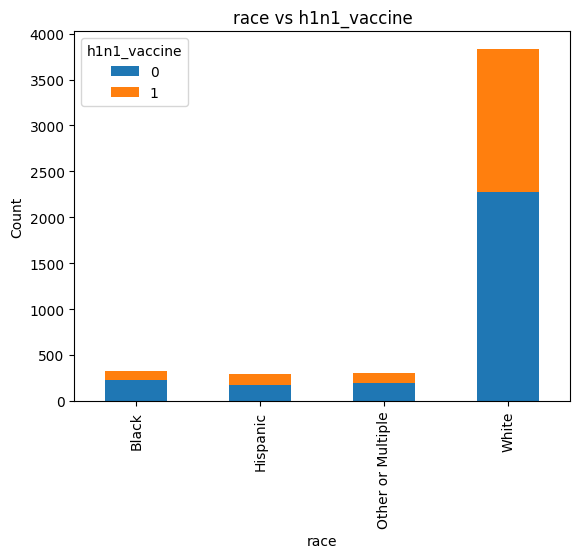

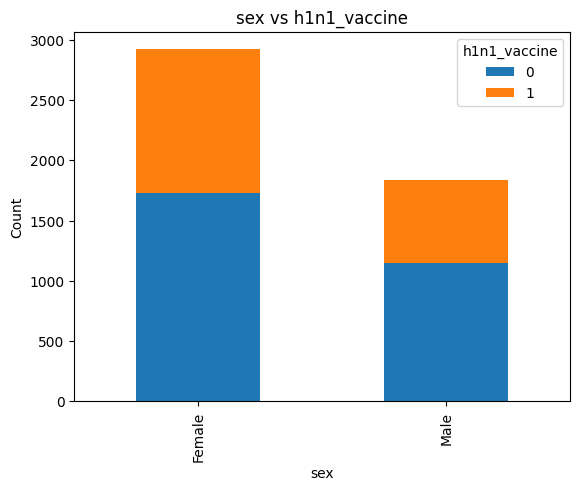

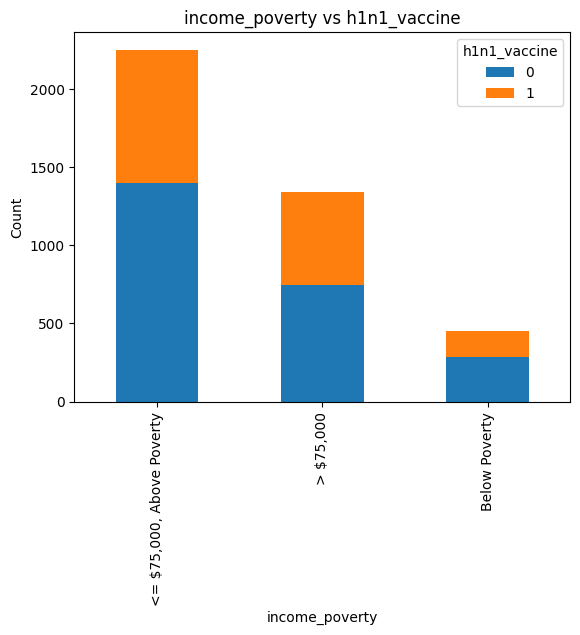

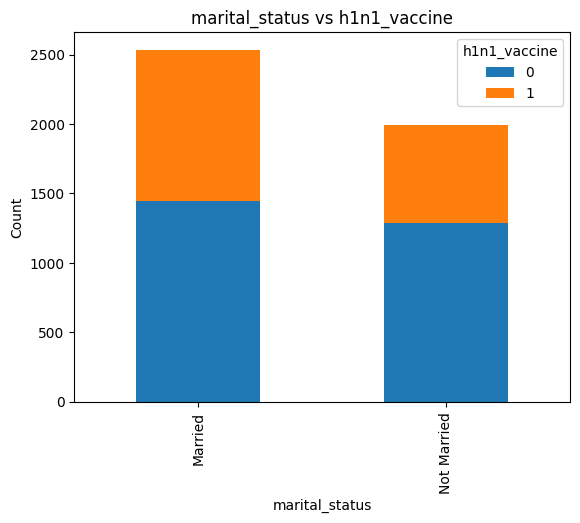

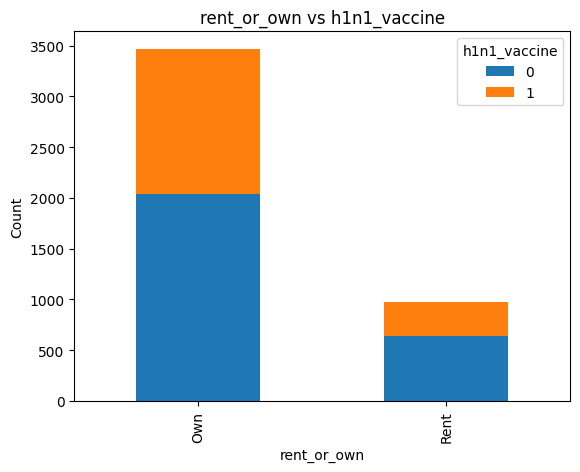

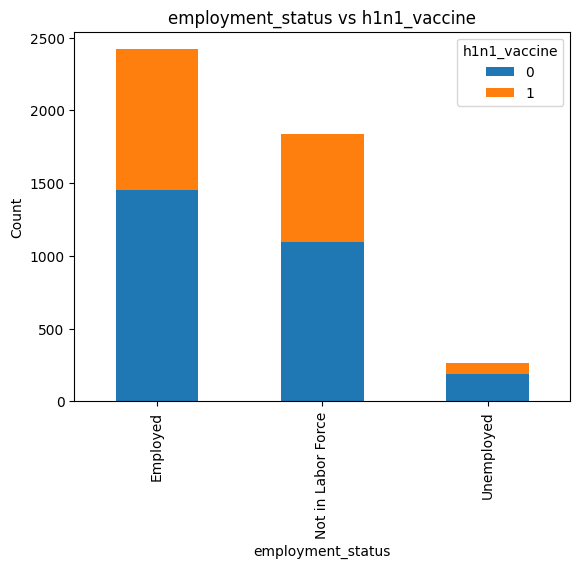

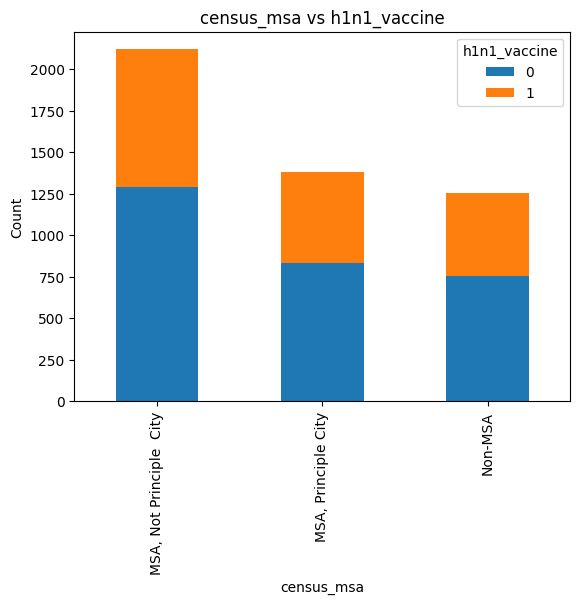

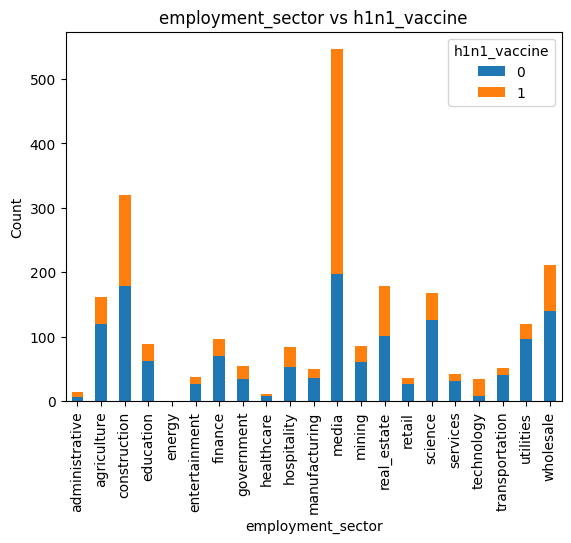

In [9]:
# Categoricals vs Target Barplots
for col in cat_cols:
    if target_col in df.columns:
        ct = pd.crosstab(df[col], df[target_col])
        ct.plot(kind='bar', stacked=True)
        plt.title(f"{col} vs {target_col}")
        plt.xlabel(col)
        plt.ylabel("Count")
        plt.show()


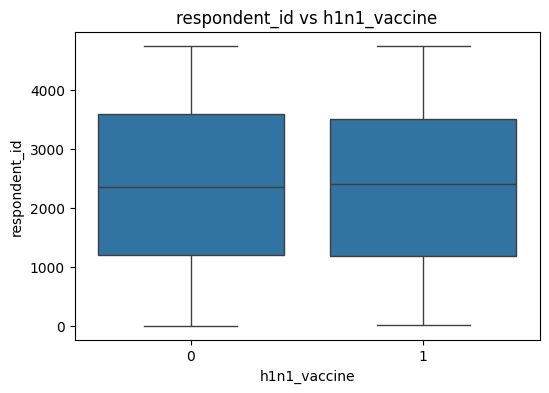

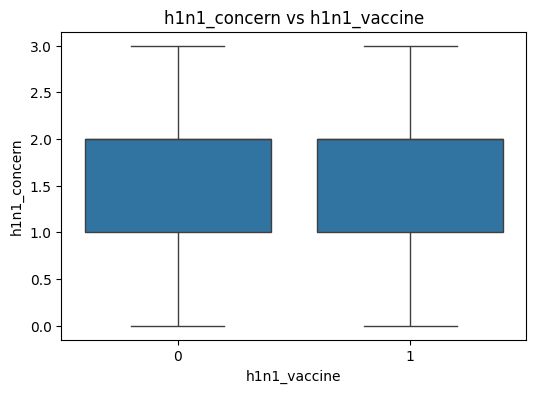

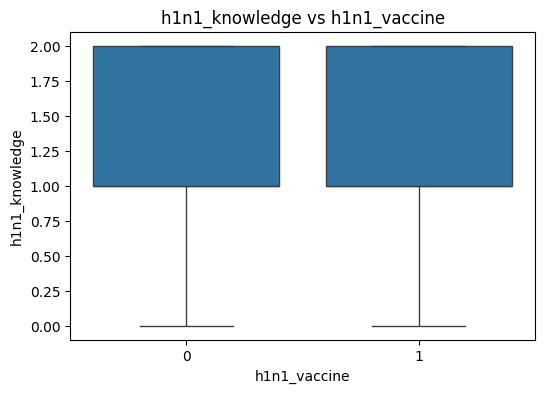

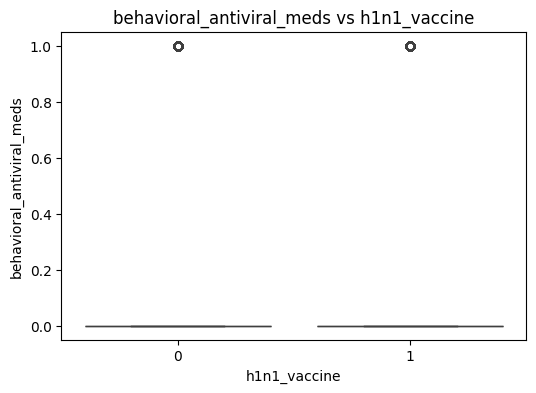

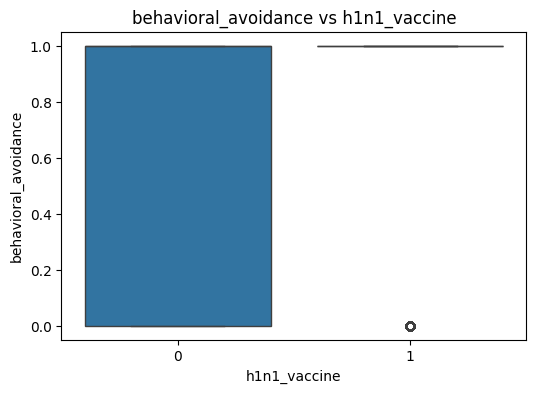

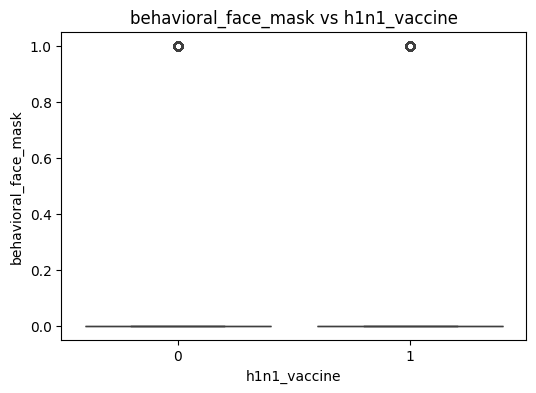

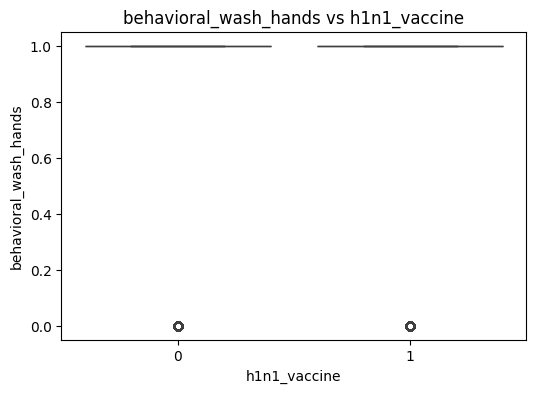

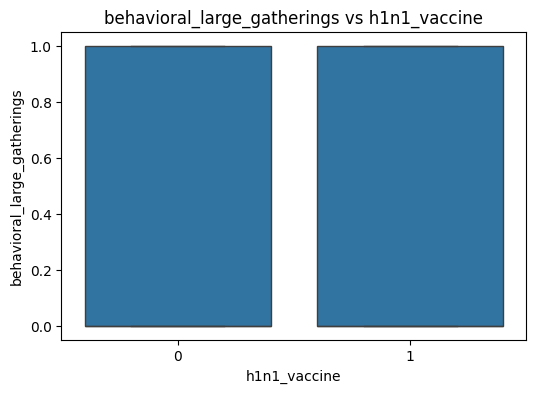

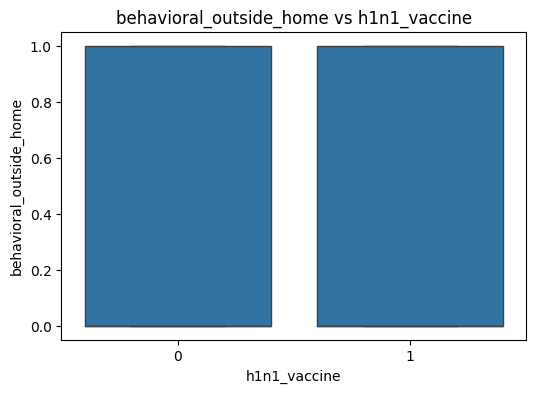

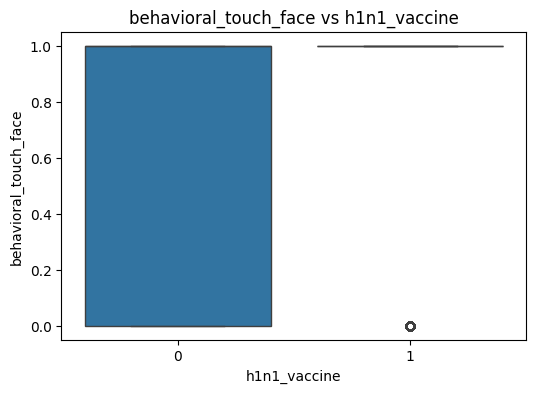

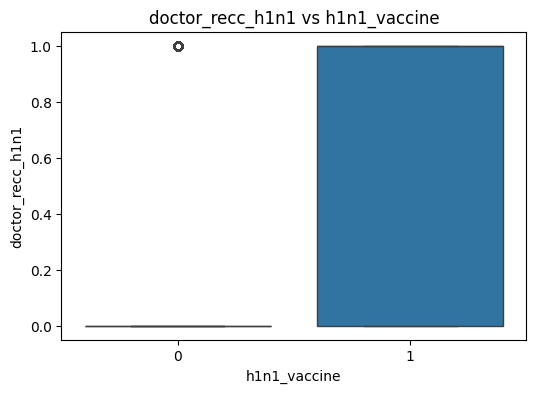

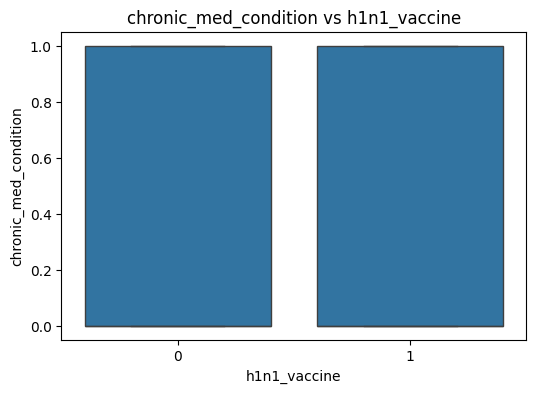

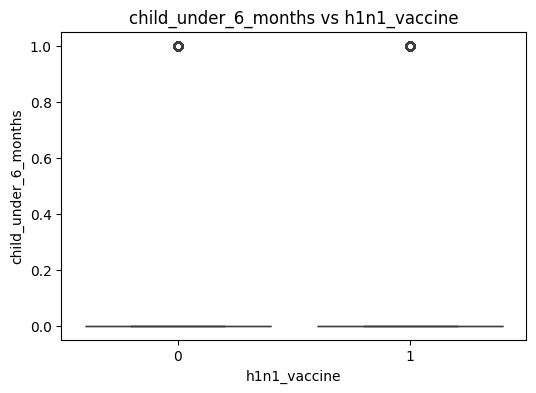

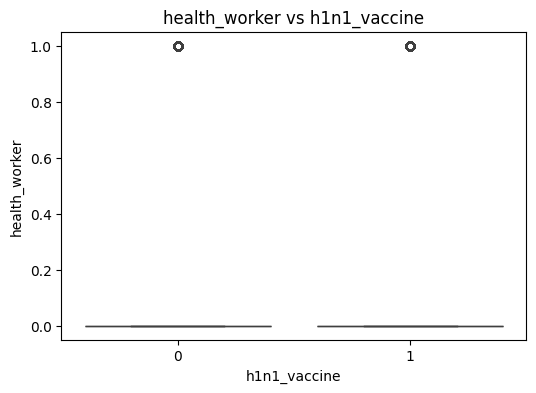

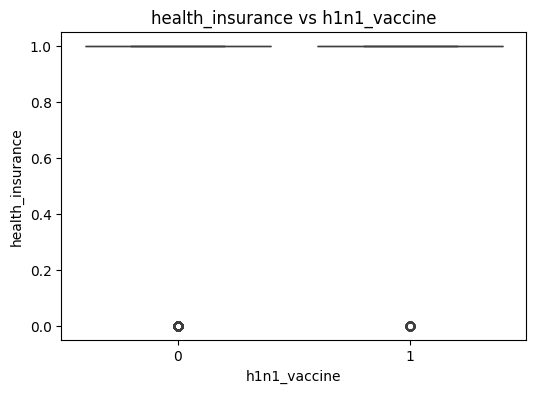

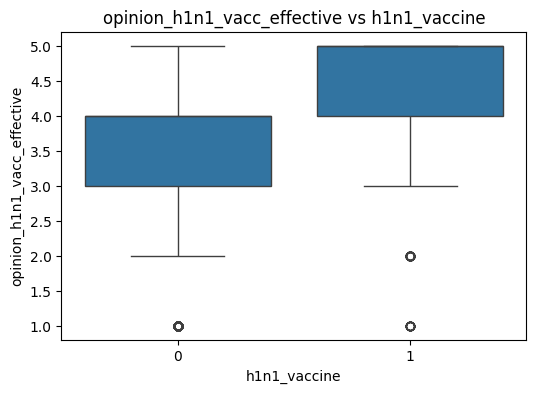

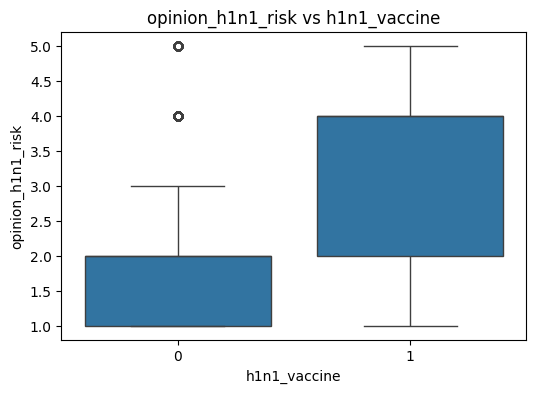

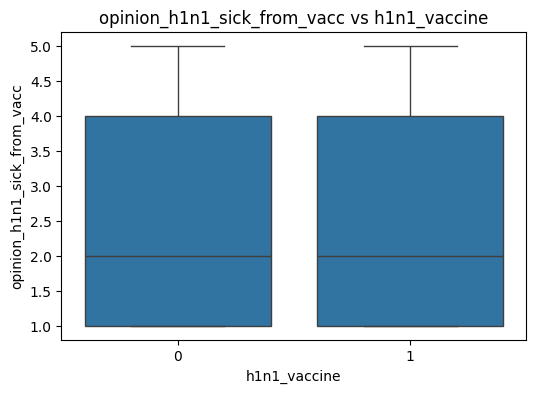

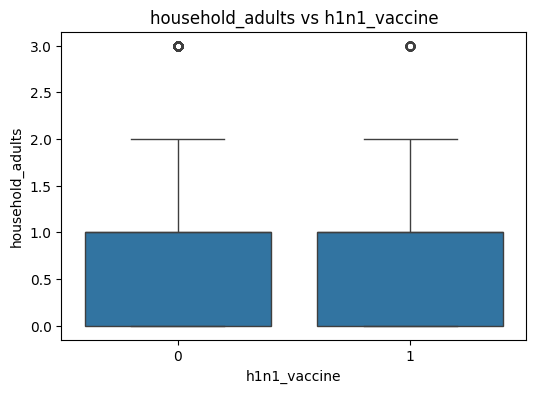

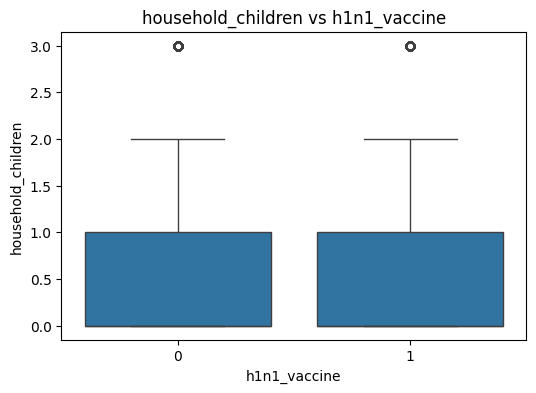

In [10]:
# Numeric vs Target

for col in num_cols:
    if col != target_col:
        plt.figure(figsize=(6,4))
        sns.boxplot(x=target_col, y=col, data=df)
        plt.title(f"{col} vs {target_col}")
        plt.show()


In [11]:
# Multivariate Analysis

# Correlation heatmap with target
if target_col in num_cols:
    corr_target = corr[[target_col]].sort_values(by=target_col, ascending=False)
    print("\nCorrelation with Target:\n", corr_target)



Correlation with Target:
                              h1n1_vaccine
h1n1_vaccine                     1.000000
doctor_recc_h1n1                 0.413874
opinion_h1n1_risk                0.362183
opinion_h1n1_vacc_effective      0.325057
health_worker                    0.205428
h1n1_knowledge                   0.148766
h1n1_concern                     0.143235
health_insurance                 0.129246
chronic_med_condition            0.107138
behavioral_touch_face            0.103222
behavioral_wash_hands            0.092827
opinion_h1n1_sick_from_vacc      0.084216
behavioral_face_mask             0.080143
child_under_6_months             0.070477
behavioral_antiviral_meds        0.059567
behavioral_avoidance             0.045791
household_adults                 0.017463
behavioral_outside_home          0.017434
household_children               0.014124
behavioral_large_gatherings      0.005598
respondent_id                   -0.008846


In [12]:
# Feature Groups & Encoders

binary_features = [
    'behavioral_antiviral_meds','behavioral_avoidance','behavioral_face_mask',
    'behavioral_wash_hands','behavioral_large_gatherings','behavioral_outside_home',
    'behavioral_touch_face','doctor_recc_h1n1','chronic_med_condition',
    'child_under_6_months','health_worker','health_insurance'
]

ordinal_features = [
    'h1n1_concern','h1n1_knowledge','opinion_h1n1_vacc_effective',
    'opinion_h1n1_risk','opinion_h1n1_sick_from_vacc',
    'education','income_poverty','age_group'
]

nominal_features = [
    'race','sex','marital_status','rent_or_own',
    'employment_status','census_msa'
]

numeric_features = ['household_adults','household_children']

ordinal_order = {
    "education": ["< 12 Years","12 Years","Some College","College Graduate"],
    "income_poverty": ["Below Poverty","<= $75,000, Above Poverty","> $75,000"],
    "age_group": ["18 - 34 Years","35 - 44 Years","45 - 54 Years","55 - 64 Years","65+ Years"]
}

manual_ordinals = [col for col in ordinal_order.keys()]

auto_ordinals = [col for col in ordinal_features if col not in manual_ordinals]

manual_ordinal_encoder = OrdinalEncoder(
    categories=[ordinal_order[col] for col in manual_ordinals],
    handle_unknown='use_encoded_value', unknown_value=np.nan
)

auto_ordinal_encoder = OrdinalEncoder(
    handle_unknown='use_encoded_value', unknown_value=np.nan
)


In [13]:
# Imputation, Encoding & Scaling

num_imputer = SimpleImputer(strategy='median')
binary_imputer = SimpleImputer(strategy='most_frequent')
cat_imputer = SimpleImputer(strategy='constant', fill_value='Unknown')
ord_imputer = SimpleImputer(strategy='most_frequent')
onehot_encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
scaler = StandardScaler()

# Tree-friendly preprocessing
preprocessor_tree = ColumnTransformer([
    ('num', num_imputer, numeric_features),
    ('bin', binary_imputer, binary_features),
    ('manual_ord', Pipeline([
        ('imputer', ord_imputer),
        ('encoder', manual_ordinal_encoder)
    ]), manual_ordinals),
    ('auto_ord', Pipeline([
        ('imputer', ord_imputer),
        ('encoder', auto_ordinal_encoder)
    ]), auto_ordinals),
    ('cat', Pipeline([
        ('imputer', cat_imputer),
        ('encoder', onehot_encoder)
    ]), nominal_features)
])

#Scaled preprocessing (for linear/KNN/SVM/NN)
preprocessor_scaled = ColumnTransformer([
    ('num', Pipeline([
        ('imputer', num_imputer),
        ('scaler', scaler)
    ]), numeric_features),
    ('bin', binary_imputer, binary_features),
    ('manual_ord', Pipeline([
        ('imputer', ord_imputer),
        ('encoder', manual_ordinal_encoder),
        ('scaler', scaler)
    ]), manual_ordinals),
    ('auto_ord', Pipeline([
        ('imputer', ord_imputer),
        ('encoder', auto_ordinal_encoder),
        ('scaler', scaler)
    ]), auto_ordinals),
    ('cat', Pipeline([
        ('imputer', cat_imputer),
        ('encoder', onehot_encoder)
    ]), nominal_features)
])


In [17]:
# Separate features (X) and target (y)

X = df.drop(columns=[target_col, "respondent_id"])
y = df[target_col]

print("Features (X) and target (y) separated successfully")
print("Shape of X:", X.shape)
print("Shape of y:", y.shape)

Features (X) and target (y) separated successfully
Shape of X: (4756, 29)
Shape of y: (4756,)


In [18]:
# Model Setup

models = {
    "Logistic Regression": LogisticRegression(max_iter=500),
    "k-Nearest Neighbors": KNeighborsClassifier(),
    "Naive Bayes": GaussianNB(),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "XGBoost": XGBClassifier(
        random_state=42, use_label_encoder=False, eval_metric='logloss'
    ),
    "Support Vector Machine": SVC(probability=True, random_state=42),
    "Neural Network (MLP)": MLPClassifier(hidden_layer_sizes=(64,32), max_iter=500, random_state=42)
}

# Train/Test Split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.33, random_state=42, stratify=y
)

In [19]:
# Training Loop (With and Without Preprocessing)

results = []

for name, model in models.items():
    # Select preprocessor
    if name in ["Logistic Regression", "k-Nearest Neighbors", "Support Vector Machine", "Neural Network (MLP)", "Naive Bayes"]:
        preprocessor = preprocessor_scaled
    else:
        preprocessor = preprocessor_tree

    # With Preprocessing
    pipe = Pipeline([
        ('preprocess', preprocessor),
        ('model', model)
    ])

    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)

    # Safe probability handling
    if hasattr(pipe, "predict_proba"):
        y_prob_temp = pipe.predict_proba(X_test)
        if y_prob_temp.ndim == 2 and y_prob_temp.shape[1] > 1:
            y_prob = y_prob_temp[:, 1]
        else:
            y_prob = y_prob_temp.ravel()
    elif hasattr(pipe, "decision_function"):
        y_prob = pipe.decision_function(X_test)
    else:
        y_prob = y_pred

    results.append({
        "Model": name,
        "Version": "With Preprocessing",
        "ROC-AUC": roc_auc_score(y_test, y_prob),
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall": recall_score(y_test, y_pred, zero_division=0),
        "F1": f1_score(y_test, y_pred)
    })

    # Without Preprocessing
    try:
        model.fit(X_train.select_dtypes(include=[np.number]).fillna(0), y_train)
        y_pred_raw = model.predict(X_test.select_dtypes(include=[np.number]).fillna(0))

        if hasattr(model, "predict_proba"):
            y_prob_raw_temp = model.predict_proba(X_test.select_dtypes(include=[np.number]).fillna(0))
            if y_prob_raw_temp.ndim == 2 and y_prob_raw_temp.shape[1] > 1:
                y_prob_raw = y_prob_raw_temp[:, 1]
            else:
                y_prob_raw = y_prob_raw_temp.ravel()
        elif hasattr(model, "decision_function"):
            y_prob_raw = model.decision_function(X_test.select_dtypes(include=[np.number]).fillna(0))
        else:
            y_prob_raw = y_pred_raw

        results.append({
            "Model": name,
            "Version": "Without Preprocessing",
            "ROC-AUC": roc_auc_score(y_test, y_prob_raw),
            "Accuracy": accuracy_score(y_test, y_pred_raw),
            "Precision": precision_score(y_test, y_pred_raw, zero_division=0),
            "Recall": recall_score(y_test, y_pred_raw, zero_division=0),
            "F1": f1_score(y_test, y_pred_raw)
        })

    except Exception as e:
        results.append({
            "Model": name,
            "Version": "Without Preprocessing",
            "ROC-AUC": np.nan,
            "Accuracy": np.nan,
            "Precision": np.nan,
            "Recall": np.nan,
            "F1": np.nan
        })
        print(f"Skipped raw model for {name}: {e}")


In [20]:
# Results Summary

results_df = pd.DataFrame(results)
results_df = results_df.sort_values(by=["Model", "Version"]).reset_index(drop=True)

print("\n=== Model Comparison (With vs Without Preprocessing) ===\n")
print(results_df.round(4).to_string(index=False))

# Save to a CSV file
results_df.to_csv("model_comparison_results.csv", index=False)



=== Model Comparison (With vs Without Preprocessing) ===

                 Model               Version  ROC-AUC  Accuracy  Precision  Recall     F1
         Decision Tree    With Preprocessing   0.6785    0.6904     0.6044  0.6220 0.6131
         Decision Tree Without Preprocessing   0.6866    0.7000     0.6209  0.6139 0.6174
   Logistic Regression    With Preprocessing   0.8150    0.7599     0.7318  0.6171 0.6696
   Logistic Regression Without Preprocessing   0.8301    0.7732     0.7449  0.6462 0.6920
           Naive Bayes    With Preprocessing   0.7656    0.7229     0.6460  0.6575 0.6517
           Naive Bayes Without Preprocessing   0.7768    0.7210     0.6526  0.6252 0.6386
  Neural Network (MLP)    With Preprocessing   0.7338    0.6917     0.6090  0.6090 0.6090
  Neural Network (MLP) Without Preprocessing   0.8057    0.7484     0.6972  0.6397 0.6672
         Random Forest    With Preprocessing   0.7983    0.7452     0.7135  0.5913 0.6466
         Random Forest Without Preprocess

In [21]:
# Model Parameter Grids

param_grids = {
    "Logistic Regression": {
        "model__C": [0.01, 0.1, 1, 10],
        "model__penalty": ['l2'],
        "model__solver": ['lbfgs', 'liblinear']
    },
    "k-Nearest Neighbors": {
        "model__n_neighbors": [3, 5, 7, 9, 11],
        "model__weights": ['uniform', 'distance'],
        "model__p": [1, 2]
    },
    "Naive Bayes": {},  # no major tunables for GaussianNB
    "Decision Tree": {
        "model__max_depth": [3, 5, 10, 15, None],
        "model__min_samples_split": [2, 5, 10],
        "model__criterion": ['gini', 'entropy']
    },
    "Random Forest": {
        "model__n_estimators": [100, 200, 300],
        "model__max_depth": [5, 10, 20, None],
        "model__min_samples_split": [2, 5, 10],
        "model__bootstrap": [True, False]
    },
    "XGBoost": {
        "model__n_estimators": [100, 200, 400],
        "model__learning_rate": [0.01, 0.05, 0.1],
        "model__max_depth": [3, 5, 7],
        "model__subsample": [0.7, 0.9, 1.0],
        "model__colsample_bytree": [0.7, 0.9, 1.0]
    },
    "Support Vector Machine": {
        "model__C": [0.1, 1, 10],
        "model__kernel": ['linear', 'rbf', 'poly'],
        "model__gamma": ['scale', 'auto']
    },
    "Neural Network (MLP)": {
        "model__hidden_layer_sizes": [(64,), (128,), (64, 32)],
        "model__activation": ['relu', 'tanh'],
        "model__alpha": [0.0001, 0.001, 0.01],
        "model__learning_rate_init": [0.001, 0.01]
    }
}

In [22]:
from sklearn.model_selection import train_test_split, RandomizedSearchCV

In [23]:
# Randomized Search and Evaluation

tuned_results = []

for name, model in models.items():
    print(f"\n Tuning {name} ...")

    preprocessor = preprocessor_scaled if name in [
        "Logistic Regression", "k-Nearest Neighbors",
        "Support Vector Machine", "Neural Network (MLP)", "Naive Bayes"
    ] else preprocessor_tree

    pipe = Pipeline([
        ('preprocess', preprocessor),
        ('model', model)
    ])

    params = param_grids.get(name, {})
    if params:
        search = RandomizedSearchCV(
            pipe, param_distributions=params, n_iter=10,
            scoring='roc_auc', cv=5, random_state=42, n_jobs=-1, verbose=1
        )
    else:
        # For models without tunable params (Naive Bayes)
        search = pipe

    # Fit
    if isinstance(search, RandomizedSearchCV):
        search.fit(X_train, y_train)
        best_model = search.best_estimator_
        best_params = search.best_params_
    else:
        search.fit(X_train, y_train)
        best_model = search
        best_params = "Default"

    # Evaluate
    y_pred = best_model.predict(X_test)
    if hasattr(best_model, "predict_proba"):
        y_prob = best_model.predict_proba(X_test)[:, 1]
    elif hasattr(best_model, "decision_function"):
        y_prob = best_model.decision_function(X_test)
    else:
        y_prob = y_pred

    tuned_results.append({
        "Model": name,
        "Best Params": best_params,
        "ROC-AUC": roc_auc_score(y_test, y_prob),
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall": recall_score(y_test, y_pred, zero_division=0),
        "F1": f1_score(y_test, y_pred)
    })



 Tuning Logistic Regression ...
Fitting 5 folds for each of 8 candidates, totalling 40 fits

 Tuning k-Nearest Neighbors ...
Fitting 5 folds for each of 10 candidates, totalling 50 fits

 Tuning Naive Bayes ...

 Tuning Decision Tree ...
Fitting 5 folds for each of 10 candidates, totalling 50 fits

 Tuning Random Forest ...
Fitting 5 folds for each of 10 candidates, totalling 50 fits

 Tuning XGBoost ...
Fitting 5 folds for each of 10 candidates, totalling 50 fits

 Tuning Support Vector Machine ...
Fitting 5 folds for each of 10 candidates, totalling 50 fits

 Tuning Neural Network (MLP) ...
Fitting 5 folds for each of 10 candidates, totalling 50 fits


In [24]:
# Convert to DataFrame
tuned_df = pd.DataFrame(tuned_results).sort_values(by="ROC-AUC", ascending=False).reset_index(drop=True)

# Print best hyperparameters
print("\n Best Hyperparameters for Each Model\n")
for i, row in tuned_df.iterrows():
    print(f"Model: {row['Model']}")
    print(f"Best Params: {row['Best Params']}\n")



 Best Hyperparameters for Each Model

Model: Support Vector Machine
Best Params: {'model__kernel': 'linear', 'model__gamma': 'scale', 'model__C': 0.1}

Model: Logistic Regression
Best Params: {'model__solver': 'lbfgs', 'model__penalty': 'l2', 'model__C': 0.1}

Model: XGBoost
Best Params: {'model__subsample': 0.7, 'model__n_estimators': 400, 'model__max_depth': 7, 'model__learning_rate': 0.01, 'model__colsample_bytree': 0.7}

Model: Random Forest
Best Params: {'model__n_estimators': 200, 'model__min_samples_split': 2, 'model__max_depth': 10, 'model__bootstrap': True}

Model: Decision Tree
Best Params: {'model__min_samples_split': 2, 'model__max_depth': 3, 'model__criterion': 'entropy'}

Model: Naive Bayes
Best Params: Default

Model: Neural Network (MLP)
Best Params: {'model__learning_rate_init': 0.01, 'model__hidden_layer_sizes': (128,), 'model__alpha': 0.0001, 'model__activation': 'tanh'}

Model: k-Nearest Neighbors
Best Params: {'model__weights': 'distance', 'model__p': 1, 'model__n

In [25]:
# Print model performance metrics
print("\n Model Performance Metrics (Sorted by ROC-AUC) \n")
metric_cols = ["Model", "ROC-AUC", "Accuracy", "Precision", "Recall", "F1"]
print(tuned_df[metric_cols].round(4).to_string(index=False))




 Model Performance Metrics (Sorted by ROC-AUC) 

                 Model  ROC-AUC  Accuracy  Precision  Recall     F1
Support Vector Machine   0.8146    0.7637     0.7460  0.6074 0.6696
   Logistic Regression   0.8145    0.7605     0.7332  0.6171 0.6702
               XGBoost   0.8144    0.7580     0.7294  0.6139 0.6667
         Random Forest   0.8121    0.7599     0.7440  0.5961 0.6619
         Decision Tree   0.7817    0.7465     0.7600  0.5218 0.6188
           Naive Bayes   0.7656    0.7229     0.6460  0.6575 0.6517
  Neural Network (MLP)   0.7471    0.7025     0.6293  0.5977 0.6131
   k-Nearest Neighbors   0.7380    0.7217     0.7013  0.5121 0.5920


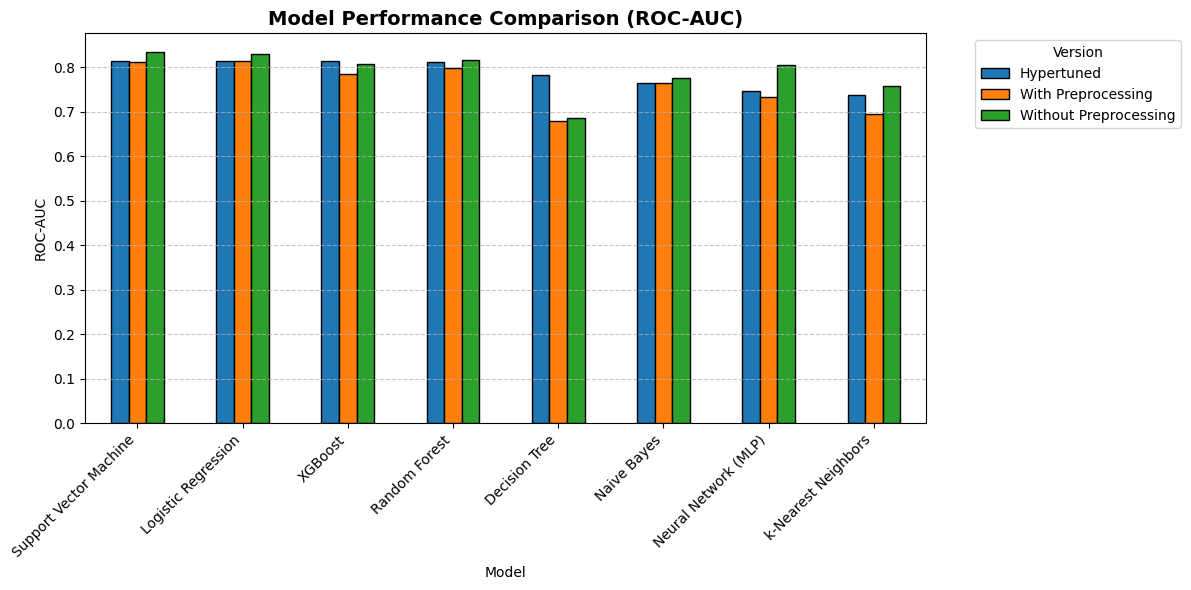

In [26]:
# Convert tuned results to DataFrame
tuned_df = pd.DataFrame(tuned_results)
tuned_df["Version"] = "Hypertuned"

# Select relevant columns
tuned_df = tuned_df[["Model", "Version", "ROC-AUC", "Accuracy", "Precision", "Recall", "F1"]]

# Combine all results
combined_df = pd.concat([results_df, tuned_df], ignore_index=True)

# Choose which metric to plot (you can change this to 'Accuracy', 'Precision', etc.)
metric = "ROC-AUC"

# Pivot data for plotting
pivot_df = combined_df.pivot(index="Model", columns="Version", values=metric)

# Sort by hypertuned performance (optional)
pivot_df = pivot_df.sort_values(by="Hypertuned", ascending=False)

# Plot
pivot_df.plot(kind="bar", figsize=(12, 6), edgecolor='black')

plt.title(f"Model Performance Comparison ({metric})", fontsize=14, fontweight='bold')
plt.ylabel(metric)
plt.xlabel("Model")
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(title="Version", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


In [27]:

# Convert results to DataFrame
results_df = pd.DataFrame(tuned_results)

results_df["Mean Score"] = results_df[["ROC-AUC", "F1"]].mean(axis=1)
top5_combined = results_df.sort_values(by="Mean Score", ascending=False).head(5)
print("\n Top 5 Models by Combined ROC-AUC & F1:")
print(top5_combined[["Model", "ROC-AUC", "F1", "Mean Score"]].to_string(index=False))


 Top 5 Models by Combined ROC-AUC & F1:
                 Model  ROC-AUC       F1  Mean Score
   Logistic Regression 0.814471 0.670175    0.742323
Support Vector Machine 0.814556 0.669635    0.742096
               XGBoost 0.814419 0.666667    0.740543
         Random Forest 0.812064 0.661883    0.736974
           Naive Bayes 0.765632 0.651721    0.708677
